In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv("spam.csv", encoding="latin-1")
print(df.head())
print("\nDataset Info:\n")
df.info()

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dty


Missing Values:
 label      0
message    0
dtype: int64


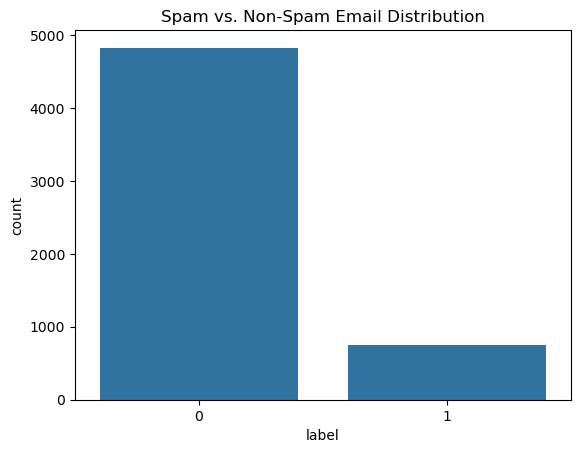

In [4]:
df = df.iloc[:, [0, 1]] 
df.columns = ['label', 'message']  
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print("\nMissing Values:\n", df.isnull().sum())
sns.countplot(x=df['label'])
plt.title("Spam vs. Non-Spam Email Distribution")
plt.show()

In [6]:
def clean_text(text):
    text = text.lower()  
    text = re.sub(r'\d+', '', text)  
    text = text.translate(str.maketrans('', '', string.punctuation))  
    text = text.strip()  
    return text
df['cleaned_message'] = df['message'].apply(clean_text)
print(df.head())

   label                                            message  \
0      0  Go until jurong point, crazy.. Available only ...   
1      0                      Ok lar... Joking wif u oni...   
2      1  Free entry in 2 a wkly comp to win FA Cup fina...   
3      0  U dun say so early hor... U c already then say...   
4      0  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in  a wkly comp to win fa cup final...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


In [8]:
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df['cleaned_message'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (4457, 8295)
Testing Data Shape: (1115, 8295)


In [10]:
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Model Accuracy: 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



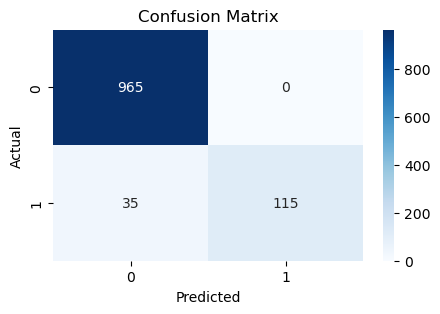

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
plt.figure(figsize=(5, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
def predict_spam(text):
    cleaned_text = clean_text(text)
    vectorized_text = vectorizer.transform([cleaned_text])
    prediction = model.predict(vectorized_text)
    return "Spam" if prediction[0] == 1 else "Not Spam"
test_email_1 = "Congratulations! You won a free iPhone. Click here to claim now!"
test_email_2 = "Hi John, can we schedule a meeting for tomorrow?"
print(f"Test Email 1: {predict_spam(test_email_1)}")
print(f"Test Email 2: {predict_spam(test_email_2)}")

Test Email 1: Spam
Test Email 2: Not Spam
